Interactive viewer ready. Click on the plot and use the LEFT/RIGHT arrow keys to navigate.


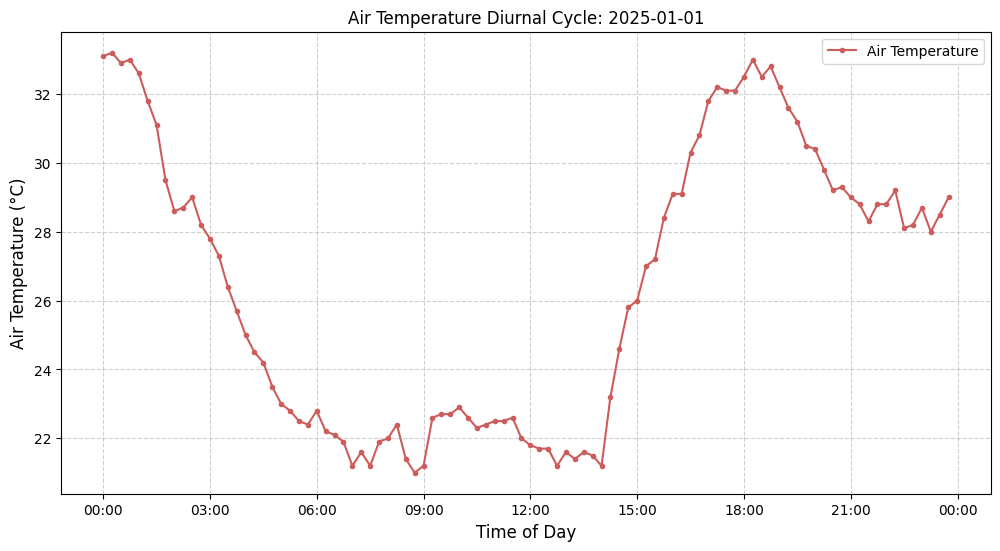

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
# If running outside Jupyter, you might need to install and set a backend:
# plt.switch_backend('TkAgg') # or 'Qt5Agg', etc.

# --- Constants ---
FILE_PATH = '../../dataset_DPIRD_utc0/202501/Kings Park.csv'
TEMP_COLUMN = 'airTemperature'

class DailyTempViewer:
    """
    Manages the data, Matplotlib figure, and key press events 
    for navigating daily temperature plots..0
    """
    def __init__(self, file_path, temp_col):
        
        # 1. Load Data
        self.df, self.dates = self._load_and_prepare_data(file_path)
        if self.df is None:
            # Cannot proceed if data loading failed
            sys.exit(1)
            
        self.temp_col = temp_col
        self.date_index = 0 # Start with the first day
        
        # 2. Setup Figure
        self.fig, self.ax = self._setup_plot()
        
        # 3. Initial Plot
        self.line = self._initial_plot()
        
        # 4. Connect Events: Bind the 'key_press_event' to the handler method
        self.fig.canvas.mpl_connect('key_press_event', self.on_key_press)
        
    def _load_and_prepare_data(self, file_path):
        """Loads and prepares data."""
        try:
            df = pd.read_csv(file_path)
            df['time'] = pd.to_datetime(df['time'])
            df.set_index('time', inplace=True)
            # FIX: Correctly extracts unique dates from the numpy array
            dates = sorted(list(set(df.index.date))) 
            return df, dates
        except Exception as e:
            print(f"Error loading data: {e}")
            return None, None

    def _setup_plot(self):
        """Creates the initial Matplotlib figure and axis."""
        fig, ax = plt.subplots(figsize=(12, 6))
        plt.xlabel('Time of Day', fontsize=12)
        plt.ylabel('Air Temperature (°C)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Set up time formatting once
        formatter = mdates.DateFormatter('%H:%M')
        ax.xaxis.set_major_formatter(formatter)
        
        return fig, ax

    def _initial_plot(self):
        """Creates the plot object for the first day."""
        current_date = self.dates[self.date_index]
        data_for_day = self.df[self.df.index.date == current_date]
        
        line, = self.ax.plot(data_for_day.index, data_for_day[self.temp_col], 
                             color='indianred', marker='o', markersize=3, 
                             linestyle='-', label='Air Temperature')
        self.ax.legend(loc='best')
        self.ax.set_title(f'Air Temperature Diurnal Cycle: {current_date}')
        return line

    def update_plot(self):
        """Updates the plot data based on the current date_index."""
        if not self.dates:
            return
            
        current_date = self.dates[self.date_index]
        data_for_day = self.df[self.df.index.date == current_date]
        
        # Update the existing line data
        self.line.set_data(data_for_day.index, data_for_day[self.temp_col])

        # Auto-scale Y-axis for the new data
        self.ax.relim()
        self.ax.autoscale_view()

        # Update title for current date
        self.ax.set_title(f'Air Temperature Diurnal Cycle: {current_date}')
        
        # Redraw the canvas to show the changes
        self.fig.canvas.draw_idle()

    def on_key_press(self, event):
        """Handles key press events for navigation."""
        if event.key == 'right':
            # Move to the next day, wrapping around to the start if needed
            self.date_index = (self.date_index + 1) % len(self.dates)
            self.update_plot()
        elif event.key == 'left':
            # Move to the previous day, wrapping around to the end if needed
            self.date_index = (self.date_index - 1) % len(self.dates)
            self.update_plot()
        
        print(f"Navigated to: {self.dates[self.date_index]}")
        
    def show(self):
        """Starts the interactive Matplotlib window."""
        # This function starts the Matplotlib event loop
        plt.show()

# --- Main Execution Block ---

if __name__ == "__main__":
    
    # 1. Initialize the viewer object
    viewer = DailyTempViewer(FILE_PATH, TEMP_COLUMN)
    
    # 2. Start the interactive plot
    # NOTE: Run this in a Jupyter Notebook/Lab environment or a Python shell 
    # with a GUI backend (like TkAgg) for the arrow keys to work.
    print("Interactive viewer ready. Click on the plot and use the LEFT/RIGHT arrow keys to navigate.")
    viewer.show()